In [ ]:
import tensorflow as tf
(xtrain, ytrain), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

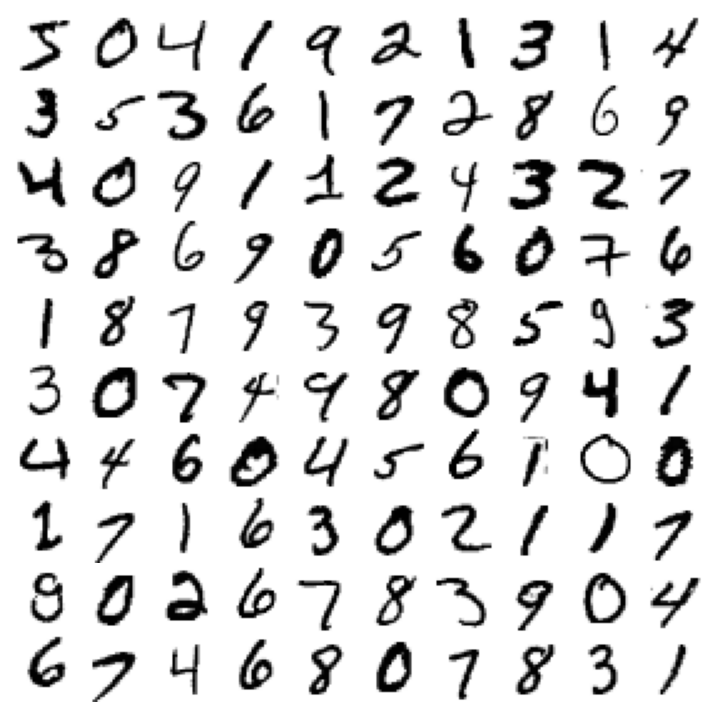

In [ ]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(xtrain[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [ ]:
import numpy as np
#dividimos los datos de entrenamiento para obtener un 20% de datos de validación
from sklearn.model_selection import train_test_split
xtrain = xtrain/255.0
x_test = x_test/255.0
ytrain = ytrain.astype(np.int32)
y_test = y_test.astype(np.int32)
x_train, x_val, y_train, y_val = train_test_split(xtrain,ytrain, test_size=0.2, random_state=42)

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy',
                               mode="max",restore_best_weights=True, patience=4)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
num_clases = 10
tf.random.set_seed(42)
print(x_train.shape)
model = Sequential([
    Flatten(input_shape=(x_train.shape[1],x_train.shape[2])),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(num_clases, activation="softmax")
])

opt = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=opt,
              metrics=["accuracy"])
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val), # Usamos los datos de validación separados
    verbose=1,
    callbacks=[early_stopping]
)


(48000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8802 - loss: 0.3804 - val_accuracy: 0.9491 - val_loss: 0.1762
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9527 - loss: 0.1641 - val_accuracy: 0.9507 - val_loss: 0.1792
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9619 - loss: 0.1378 - val_accuracy: 0.9581 - val_loss: 0.1596
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9652 - loss: 0.1274 - val_accuracy: 0.9647 - val_loss: 0.1427
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9686 - loss: 0.1152 - val_accuracy: 0.9563 - val_loss: 0.1713
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9740 - loss: 0.1016 - val_accuracy: 0.9598 - val_loss: 0.1648
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9756 - loss: 0.0926 - val_accuracy: 0.9611 - val_loss: 0.1975
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9765 - loss: 0.0883 - val_accuracy: 0

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
nombres=['0','1','2','3','4','5','6','7','8','9']
predicciones = model.predict(x_test)
predicciones=np.argmax(predicciones,axis=1)

informe=classification_report(y_test,predicciones,target_names=nombres)
print(informe)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.96      0.96      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.95      0.98      0.96       982
           5       0.93      0.97      0.95       892
           6       0.97      0.96      0.97       958
           7       0.98      0.95      0.97      1028
           8       0.94      0.95      0.95       974
           9       0.96      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



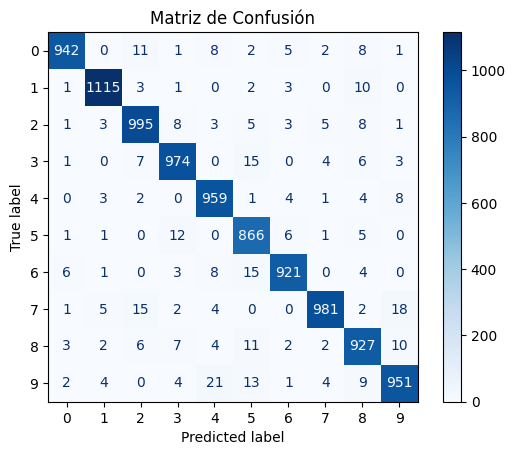

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(nombres))
disp.plot(cmap=plt.cm.Blues)


plt.title("Matriz de Confusión")
plt.show()

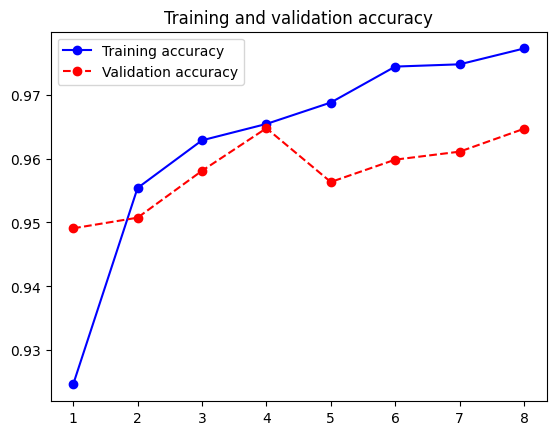

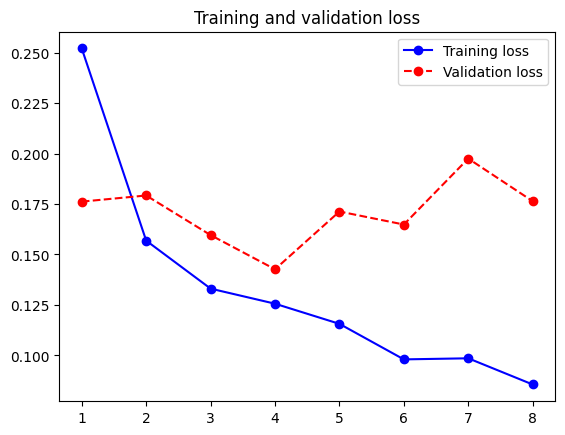

In [ ]:
def plot(history):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "b-o", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "r--o", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "b-o", label="Training loss")
    plt.plot(epochs, val_loss, "r--o", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

plot(history)